In [55]:
import pandas as pd
import matplotlib.pyplot as plt

In [56]:
df = pd.read_excel("RunningTimeRecord.xlsx", sheet_name="Testing 1", skiprows=3)

df.head()

,n,Computational Time (sec),Computational Time (sec).1,Speedup,Computational Time (sec).2,Speedup.1
0,10000000,1.981976,0.664019,2.984818,0.39406,5.02963
1,11000000,2.229783,0.760851,2.930643,0.444861,5.012314
2,12000000,2.526747,0.847935,2.979883,0.503745,5.015925
3,13000000,2.909777,0.93635,3.107574,0.56334,5.165223
4,14000000,3.193509,1.072575,2.977423,0.64324,4.964724


In [57]:
df2 = df.iloc[0:31, [0,1,4]].copy()

df2.rename(
    columns={
        "Computational Time (sec)": "serial_comp_time",
        "Computational Time (sec).2": "openmp_comp_time",},
    inplace=True)

df2

,n,serial_comp_time,openmp_comp_time
0,10000000,1.981976,0.39406
1,11000000,2.229783,0.444861
2,12000000,2.526747,0.503745
3,13000000,2.909777,0.56334
4,14000000,3.193509,0.64324
5,15000000,3.508909,0.714647
6,16000000,3.855206,0.763139
7,17000000,4.169472,0.838065
8,18000000,4.530472,0.916491
9,19000000,4.93169,0.969385


In [58]:
df3 = df.iloc[35:66, [0,1,4]].copy()

df3.rename(
    columns={
        "Computational Time (sec)": "serial_comp_time",
        "Computational Time (sec).2": "openmp_comp_time",},
    inplace=True)

df3

,n,serial_comp_time,openmp_comp_time
35,10000000,1.909535,0.1765
36,11000000,2.060715,0.144777
37,12000000,2.344162,0.140874
38,13000000,2.618735,0.151469
39,14000000,2.932696,0.166132
40,15000000,2.935181,0.183388
41,16000000,2.938532,0.199738
42,17000000,3.147916,0.221701
43,18000000,3.984353,0.237606
44,19000000,4.508056,0.259808


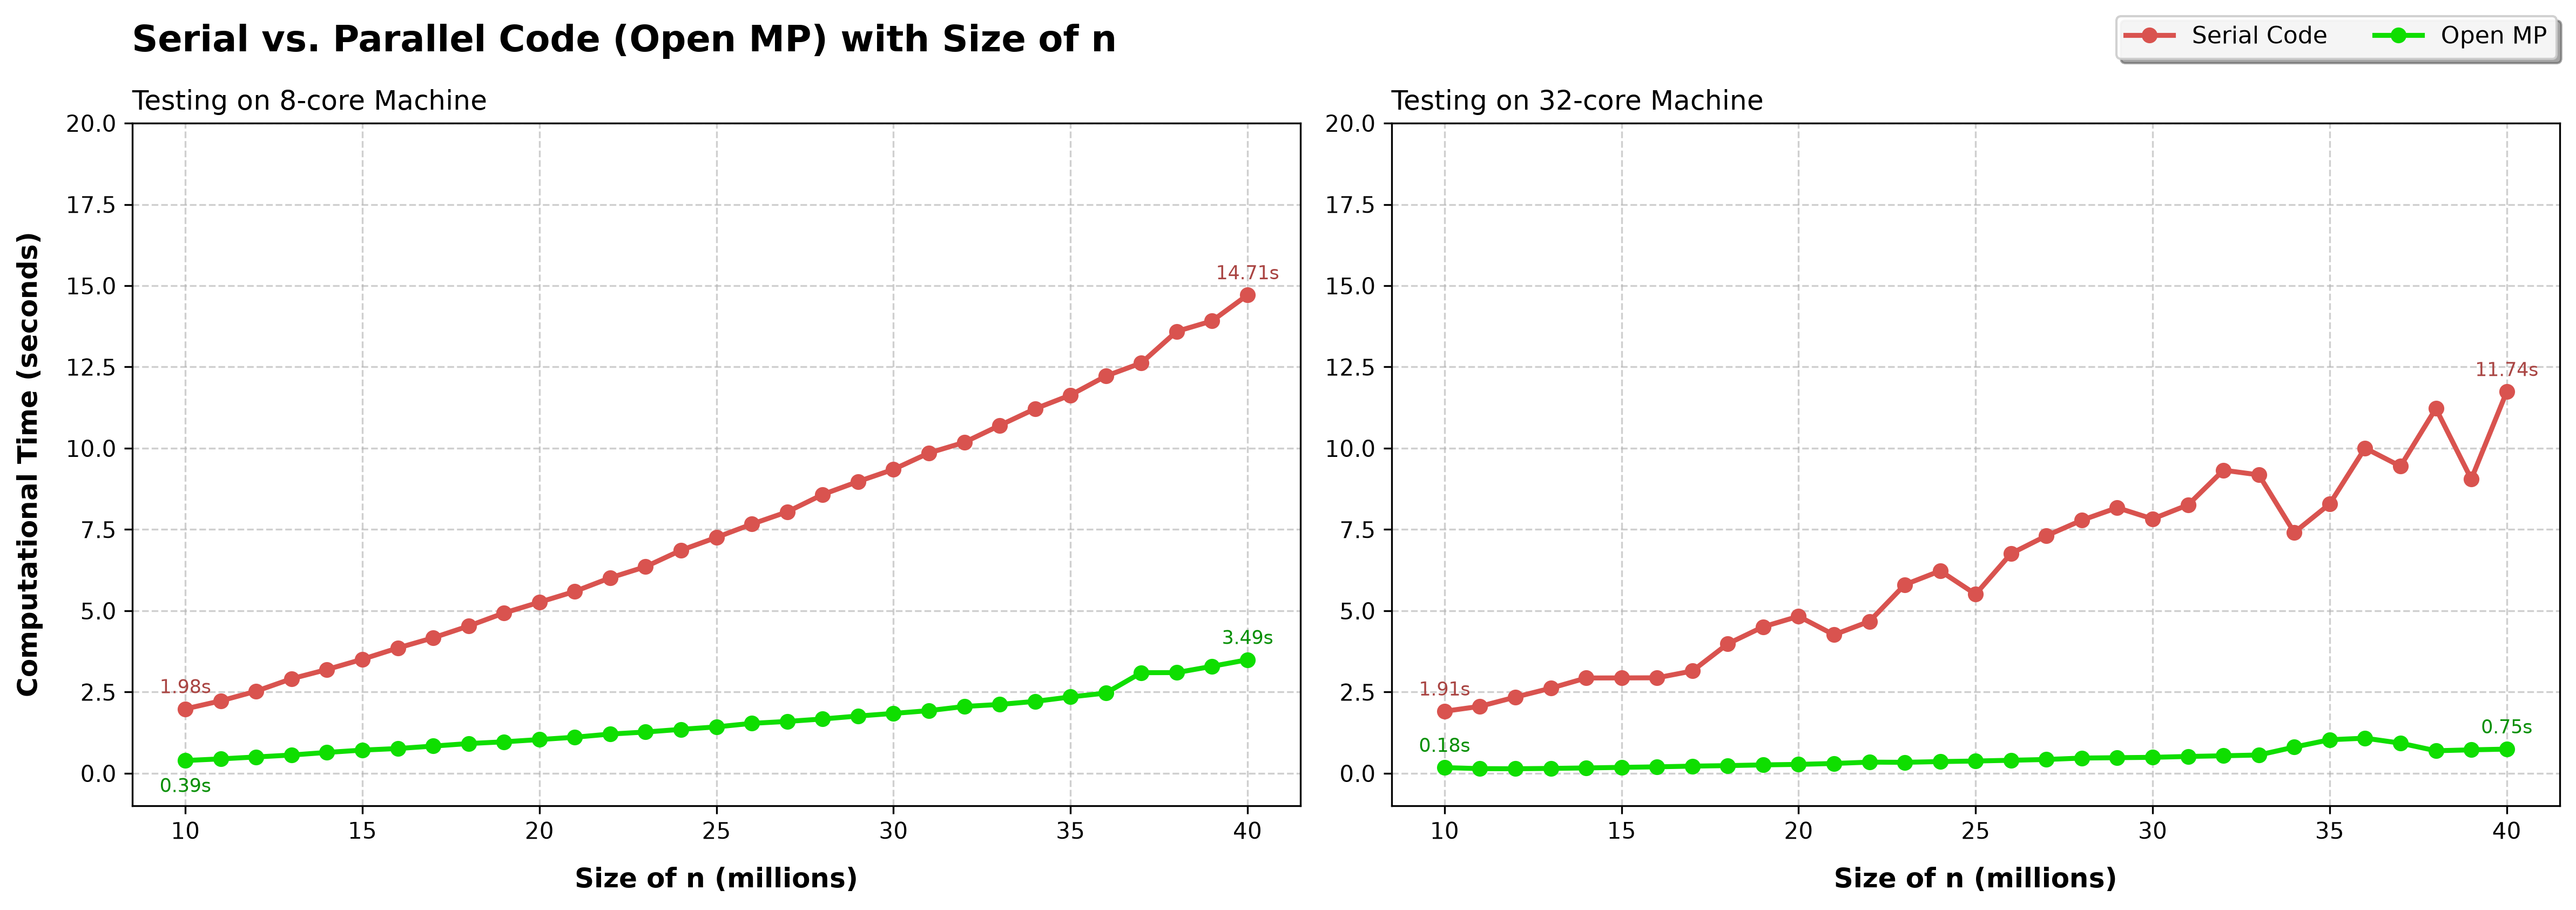

In [63]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FuncFormatter

fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=300)


# =========================
# 8-core graph
# =========================
ax = axes[0]

line1, = ax.plot(
    df2.n, df2.serial_comp_time,
    marker='o', markersize=6, linewidth=2.2,
    color='#D9534F', label='Serial Code'
)

line2, = ax.plot(
    df2.n, df2.openmp_comp_time,
    marker='o', markersize=6, linewidth=2.2,
    color="#0FDE00", label='Open MP'
)

ax.set_title(
    "Testing on 8-core Machine",
    fontsize=12,
    loc='left'
)

ax.set_xlabel(
    "Size of n (millions)",
    fontsize=12,
    fontweight='semibold',
    labelpad=10
)

ax.set_ylabel(
    "Computational Time (seconds)",
    fontsize=12,
    fontweight='semibold',
    labelpad=10
)

# X-axis: show ticks/grid every 5 million
ax.xaxis.set_major_locator(MultipleLocator(5_000_000))
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x / 1_000_000:g}")
)

ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)

ax.grid(True, linestyle='--', alpha=0.6)
ax.set_ylim(-1, 20)


# Annotations
ax.annotate(
    f"{df2.serial_comp_time.iloc[0]:.2f}s",
    (df2.n.iloc[0], df2.serial_comp_time.iloc[0]),
    textcoords='offset points',
    xytext=(0, 7),
    ha='center',
    fontsize=8.5,
    color='#A94442'
)

ax.annotate(
    f"{df2.serial_comp_time.iloc[-1]:.2f}s",
    (df2.n.iloc[-1], df2.serial_comp_time.iloc[-1]),
    textcoords='offset points',
    xytext=(0, 7),
    ha='center',
    fontsize=8.5,
    color='#A94442'
)

ax.annotate(
    f"{df2.openmp_comp_time.iloc[0]:.2f}s",
    (df2.n.iloc[0], df2.openmp_comp_time.iloc[0]),
    textcoords='offset points',
    xytext=(0, -14),
    ha='center',
    fontsize=8.5,
    color="#058F03"
)

ax.annotate(
    f"{df2.openmp_comp_time.iloc[-1]:.2f}s",
    (df2.n.iloc[-1], df2.openmp_comp_time.iloc[-1]),
    textcoords='offset points',
    xytext=(0, 7),
    ha='center',
    fontsize=8.5,
    color="#058F03"
)


# =========================
# 32-core graph
# =========================
ax = axes[1]

ax.plot(
    df3.n, df3.serial_comp_time,
    marker='o', markersize=6, linewidth=2.2,
    color='#D9534F', label='Serial Code'
)

ax.plot(
    df3.n, df3.openmp_comp_time,
    marker='o', markersize=6, linewidth=2.2,
    color="#0FDE00", label='Open MP'
)

ax.set_title(
    "Testing on 32-core Machine",
    fontsize=12,
    loc='left'
)

ax.set_xlabel(
    "Size of n (millions)",
    fontsize=12,
    fontweight='semibold',
    labelpad=10
)

# X-axis: show ticks/grid every 5 million
ax.xaxis.set_major_locator(MultipleLocator(5_000_000))
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x / 1_000_000:g}")
)

ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)

ax.grid(True, linestyle='--', alpha=0.6)
ax.set_ylim(-1, 20)


# Annotations
ax.annotate(
    f"{df3.serial_comp_time.iloc[0]:.2f}s",
    (df3.n.iloc[0], df3.serial_comp_time.iloc[0]),
    textcoords='offset points',
    xytext=(0, 7),
    ha='center',
    fontsize=8.5,
    color='#A94442'
)

ax.annotate(
    f"{df3.serial_comp_time.iloc[-1]:.2f}s",
    (df3.n.iloc[-1], df3.serial_comp_time.iloc[-1]),
    textcoords='offset points',
    xytext=(0, 7),
    ha='center',
    fontsize=8.5,
    color='#A94442'
)

ax.annotate(
    f"{df3.openmp_comp_time.iloc[0]:.2f}s",
    (df3.n.iloc[0], df3.openmp_comp_time.iloc[0]),
    textcoords='offset points',
    xytext=(0, 7),
    ha='center',
    fontsize=8.5,
    color="#058F03"
)

ax.annotate(
    f"{df3.openmp_comp_time.iloc[-1]:.2f}s",
    (df3.n.iloc[-1], df3.openmp_comp_time.iloc[-1]),
    textcoords='offset points',
    xytext=(0, 7),
    ha='center',
    fontsize=8.5,
    color="#058F03"
)


# =========================
# Overall title
# =========================
fig.suptitle(
    "Serial vs. Parallel Code (Open MP) with Size of n",
    fontsize=16,
    fontweight='bold',
    x=0.054,
    y=0.92,
    ha='left'
)


# =========================
# Overall legend
# =========================
fig.legend(
    handles=[line1, line2],
    labels=['Serial Code', 'Open MP'],
    loc='upper right',
    bbox_to_anchor=(0.994, 0.94),
    ncol=2,
    fontsize=10.5,
    frameon=True,
    framealpha=0.9,
    shadow=True
)


# =========================
# Layout & save
# =========================
plt.tight_layout(rect=[0, 0, 1, 0.94])

plt.savefig(
    "task3_graph1.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()